# Alluvial-mine classification and geographic transfer

**Training countries:** Brazil, Colombia, Ecuador, Guyana and Peru.  
**Held-out countries:** Bolivia, French Guiana, Suriname and Venezuela (cross-country); Ghana, Indonesia and Myanmar (cross-continent).

The primary evaluation levels are spatially buffered validation within the training region, transfer to held-out South American countries, and transfer to held-out continents. Pixel-, polygon- and site-level splits are retained as leakage diagnostics. The decision threshold is fixed using the spatially buffered out-of-fold predictions and is not re-tuned on held-out countries.


In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# ============================================================
# 1. Environment and configuration
# ============================================================
import os, sys, re, subprocess, warnings, json, math
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             average_precision_score, precision_recall_curve,
                             confusion_matrix)

try:
    from xgboost import XGBClassifier
except Exception:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','xgboost'])
    from xgboost import XGBClassifier

try:
    from google.colab import drive, files
    drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except Exception:
    files = None; IN_COLAB = False

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ---- fixed country allocation ---------------------------------
TRAIN_COUNTRIES = ['BRA', 'COL', 'ECU', 'GUY', 'PER']
TEST_COUNTRIES = ['BOL', 'VEN', 'GUF', 'SUR',          # cross-country
                  'GHA', 'IDN', 'MMR']                 # cross-continent

TRAIN_TPL = 'sa9_v8_train_2024_fast_{iso}.csv'
TEST_TPL  = 'sa9_v8_test_2024_fast_{iso}.csv'

# Folders searched, in order, for those filenames. The first hit wins.
SEARCH_DIRS = [Path('/content/drive/MyDrive/dissertation'),
               Path('/content/drive/MyDrive'),
               Path('/content'), Path('.')]

OUT_DIR = Path('/content/drive/MyDrive/dissertation/results_classification_transfer')
if not Path('/content/drive/MyDrive').exists():
    OUT_DIR = Path('./results_classification_transfer')
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR/'figures').mkdir(exist_ok=True)

# Maximum pixels contributed by any one polygon, so that large mine complexes
# cannot dominate the training set.
MAX_PIXELS_PER_POLYGON = 300
# Dead-zone width for T4, in km - the gold standard discussed in supervision
BUFFER_KM = 10.0
N_FOLDS = 5
N_BOOTSTRAP = 200

def _locate(name):
    """Every SEARCH_DIRS hit for one exact filename, in search order."""
    return [d / name for d in SEARCH_DIRS if (d / name).exists()]

def discover_train_files():
    """Resolve one exact training file for each pre-specified country."""
    out, missing = {}, []
    for iso in TRAIN_COUNTRIES:
        hits = _locate(TRAIN_TPL.format(iso=iso))
        if hits:
            out[iso] = hits[0]
        else:
            missing.append(iso)
    if missing:
        raise FileNotFoundError(
            'No csv found for training countries ' + str(missing))
    return out


def resolve_test_files():
    """{iso3: Path} for the held-out set, one exact filename per country."""
    out, missing = {}, []
    for iso in TEST_COUNTRIES:
        hits = _locate(TEST_TPL.format(iso=iso))
        if hits:
            out[iso] = hits[0]
        else:
            missing.append(iso)
    if missing:
        avail = sorted({q.name for d in SEARCH_DIRS
                        for q in d.glob('sa9_v8_*_2024_fast_*.csv')})
        raise FileNotFoundError(
            'No csv found for held-out countries ' + str(missing) +
            '\nFiles visible in SEARCH_DIRS:\n  ' + '\n  '.join(avail))
    return out

print('Output directory:', OUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Output directory: /content/drive/MyDrive/dissertation/results_classification_transfer


In [20]:
# ============================================================
# 2. Publication figure style (one style for every figure in the dissertation)
# ============================================================
# Categorical palette checked for colour-vision deficiency.
# Key constraint: in figures where every pair of series must be separable (e.g. scatter
# plots) only the first three colour slots may be used;
# more than three classes must be faceted rather than given more colours.

PAL = {
    'series': ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
               '#e87ba4', '#008300', '#4a3aa7', '#e34948'],
    'seq':    ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7',
               '#3987e5','#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b'],
    'surface': '#fcfcfb',
    'ink':     '#0b0b0b',
    'ink2':    '#52514e',
    'muted':   '#8a8983',
    'grid':    '#e5e4e0',
    'neutral': '#f0efec',
    'pos':     '#e34948',   # mining
    'neg':     '#2a78d6',   # non-mining
}

mpl.rcParams.update({
    'figure.dpi': 120, 'savefig.dpi': 300,
    'figure.facecolor': PAL['surface'], 'axes.facecolor': PAL['surface'],
    'savefig.facecolor': PAL['surface'], 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9,
    'axes.labelcolor': PAL['ink2'], 'text.color': PAL['ink'],
    'xtick.color': PAL['ink2'], 'ytick.color': PAL['ink2'],
    'axes.edgecolor': PAL['grid'], 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': PAL['grid'], 'grid.linewidth': 0.6,
    'legend.frameon': False, 'lines.linewidth': 2.0,
    'lines.markersize': 6,
})

from matplotlib.colors import LinearSegmentedColormap
CMAP_SEQ = LinearSegmentedColormap.from_list('seq_blue', PAL['seq'])

# Suffix every figure generated by the final classification analysis.
FIG_SUFFIX = '_final'

def save_fig(fig, name):
    for ext in ('png','pdf'):
        fig.savefig(OUT_DIR/'figures'/f'{name}{FIG_SUFFIX}.{ext}')
    print('saved:', name + FIG_SUFFIX)

In [21]:
# ============================================================
# 3. Loading the training pool
# ============================================================
# There is no parquet cache in this notebook. A cache is the single most
# dangerous failure mode here: it would silently serve a country allocation
# left over from a different run. Five csvs read in a few seconds.
print('Resolving training files by exact name:')
train_files = discover_train_files()
if not train_files:
    raise FileNotFoundError('No sa9_v8_train_2024_fast_<ISO3>.csv files found.')

frames = []
for iso, q in sorted(train_files.items()):
    f = pd.read_csv(q)
    print(f'  {iso}  {q.name}: {len(f):,} rows')
    frames.append(f)
train = pd.concat(frames, ignore_index=True)
print('Training pool:', sorted(train_files), '->', train.shape)

assert 'ECU' in train_files, (
    'ECU is not in the training pool. Expected sa9_v8_train_2024_fast_ECU.csv '
    'in one of SEARCH_DIRS.')
assert not (set(train_files) & set(TEST_COUNTRIES)), (
    'a country appears in both the training pool and TEST_COUNTRIES')

# ============================================================
# 3b. Identifier namespacing and allocation guards
# ============================================================
# Prefix Ecuador polygon and site identifiers to guarantee uniqueness across
# Geometry Import namespaces before grouped spatial validation.
assert 'ECU' in set(train['country_iso3']), (
    'ECU is not in the training table. Check that sa9_v8_train_2024_fast_ECU.csv is '
    'in a SEARCH_DIRS folder and that no stale parquet cache is being read.')

_m = train['country_iso3'] == 'ECU'
train.loc[_m, 'polygon_id'] = 'ECU_' + train.loc[_m, 'polygon_id'].astype(str)
train.loc[_m, 'site_id']    = 'ECU_' + train.loc[_m, 'site_id'].astype(str)

_ep, _op = set(train.loc[_m,'polygon_id']), set(train.loc[~_m,'polygon_id'])
_es, _os = set(train.loc[_m,'site_id']),    set(train.loc[~_m,'site_id'])
assert not (_ep & _op), 'polygon_id collision survives namespacing'
assert not (_es & _os), 'site_id collision survives namespacing'

print('Training countries:', sorted(train['country_iso3'].unique()))
print(f'ECU rows in training: {int(_m.sum()):,}   '
      f'polygons: {len(_ep)}   sites: {len(_es)}')
print('Identifier collisions after namespacing: 0 / 0')

ALPHA = [f'A{i:02d}' for i in range(64)]
S2_CANDIDATES = ['S2_B2','S2_B3','S2_B4','S2_B8','S2_B11','S2_B12',
                 'NDVI','MNDWI','NDTI','BSI','elevation','slope',
                 'dist_to_water_m','jrc_water_occurrence']
S2 = [c for c in S2_CANDIDATES if c in train.columns]

print('\n--- Data quality checks ---')
print('AlphaEarth features:', len(ALPHA), ' other features:', len(S2))

feat_all = ALPHA + S2
n_nan = train[feat_all].isna().any(axis=1).sum()
print(f'Rows with missing values: {n_nan}  ({n_nan/len(train):.2%})  -> dropped')
train = train.dropna(subset=feat_all).copy()

# Duplicate pixels: large polygons are sampled with random points, so duplicates should
# be rare; verify and remove them anyway.
train['_gx'] = (train['longitude']*1e4).round().astype(int)
train['_gy'] = (train['latitude']*1e4).round().astype(int)
dup = train.duplicated(subset=['_gx','_gy']).sum()
print(f'Duplicate pixels: {dup}  ({dup/len(train):.2%})  -> dropped')
train = train.drop_duplicates(subset=['_gx','_gy']).copy()

print('\nBy label:'); print(train['label'].value_counts().to_string())
print('\nBy positive definition:'); print(train['positive_definition'].value_counts().to_string())
print('\nBy country x class:'); print(train.groupby(['country_iso3','binary']).size().to_string())
print('\nDistinct polygons:', train['polygon_id'].nunique(),
      ' distinct sites:', train['site_id'].nunique())

pp = train.groupby('polygon_id').size().sort_values(ascending=False)
print('\nTop 10 polygons by pixel count:'); print(pp.head(10).to_string())
print(f'median {pp.median():.0f} | max {pp.max()} | total rows {len(train):,}')

Resolving training files by exact name:
  REJECTED (filename is not ..._<ISO3>.csv): sa9_v8_train_2024_fast_MERGED.csv
  BRA  sa9_v8_train_2024_fast_BRA.csv: 17,633 rows
  COL  sa9_v8_train_2024_fast_COL.csv: 8,592 rows
  ECU  sa9_v8_train_2024_fast_ECU.csv: 4,737 rows
  GUY  sa9_v8_train_2024_fast_GUY.csv: 2,655 rows
  PER  sa9_v8_train_2024_fast_PER.csv: 10,962 rows
Training pool: ['BRA', 'COL', 'ECU', 'GUY', 'PER'] -> (44579, 86)
Training countries: ['BRA', 'COL', 'ECU', 'GUY', 'PER']
ECU rows in training: 4,737   polygons: 38   sites: 18
Identifier collisions after namespacing: 0 / 0

--- Data quality checks ---
AlphaEarth features: 64  other features: 0
Rows with missing values: 0  (0.00%)  -> dropped
Duplicate pixels: 2955  (6.63%)  -> dropped

By label:
label
mine_complex_positive                     14605
turbid_braided_river_negative              4410
agriculture_negative                       3801
mine_pure_bare_positive                    2979
grassland_negative             

In [22]:
# ============================================================
# 4. Per-polygon capped subsampling
# ============================================================
# Why: mine-complex polygons are far larger than the negative boxes, so unrestricted
# sampling would let the positive class dominate.
# This is not a class-imbalance problem but a few-large-polygons-dominate-a-class problem.
# The fix is a per-polygon cap: every row is still a real pixel with intact coordinates
# and site_id, so the evaluation design is untouched. (This is also why SMOTE is rejected:
# synthetic samples have no coordinates and cannot be assigned to any fold.)

def cap_per_polygon(df, cap=MAX_PIXELS_PER_POLYGON, seed=RANDOM_SEED):
    # Index-based selection rather than groupby.apply: in recent pandas the latter turns
    # the group column into the index, and reset_index(drop=True) then loses polygon_id.
    rng = np.random.RandomState(seed)
    keep = []
    for _, g in df.groupby('polygon_id', sort=False):
        idx = g.index.values
        keep.append(idx if len(idx) <= cap
                    else rng.choice(idx, cap, replace=False))
    return df.loc[np.concatenate(keep)] if keep else df.iloc[0:0]

before = len(train)
train_c = cap_per_polygon(train).reset_index(drop=True)
print(f'After per-polygon capping: {before:,} -> {len(train_c):,} rows')
print('\nBy label after capping:'); print(train_c['label'].value_counts().to_string())
print('\nBinary class balance:'); print(train_c['binary'].value_counts().to_string())

# Site centroids, needed for the T4 distance computation
site_xy = (train_c.groupby('site_id')[['longitude','latitude']].mean()
           .rename(columns={'longitude':'lon','latitude':'lat'}))
print('\nNumber of sites:', len(site_xy))

After per-polygon capping: 41,624 -> 41,594 rows

By label after capping:
label
mine_complex_positive                     14587
turbid_braided_river_negative              4410
agriculture_negative                       3801
mine_pure_bare_positive                    2979
grassland_negative                         2949
forest_negative                            2929
agriculture_within_vegetation_negative     2794
urban_bare_negative                        2259
mine_pure_pond_turbid_positive             1878
mine_pure_pond_dark_positive               1462
river_negative                             1146
agriculture_shoreline_negative              400

Binary class balance:
binary
1    20906
0    20688

Number of sites: 155


In [23]:
# ============================================================
# 5. Feature sets and the two positive-class definitions
# ============================================================
# Only feature sets actually present in the table are registered.
# The current export is AlphaEarth-only (on-the-fly Sentinel-2 compositing was dropped
# on GEE compute-cost grounds),
# so FS-B / FS-C are skipped automatically rather than raising.
# If control features are exported later they appear here automatically.
FEATURE_SETS = {}
FEATURE_SETS['FS-A AlphaEarth'] = ALPHA
if len(S2) >= 3:
    FEATURE_SETS['FS-B Sentinel-2'] = S2
    FEATURE_SETS['FS-C Combined'] = ALPHA + S2
print('Feature sets entering the experiment:', {k: len(v) for k, v in FEATURE_SETS.items()})
if len(FEATURE_SETS) == 1:
    print('WARNING: only the AlphaEarth feature set is present - no control set.')
    print('   Dissertation S4.4 must state that the Sentinel-2 control was dropped')
    print('   on GEE compute-cost grounds (see Discussion / Limitations).')

# Definition A = the whole mine complex; Definition B = pure mining-surface boxes.
# Both share the same negatives; only which rows count as positive differs.
POSITIVE_DEFS = {
    'A_complex':      lambda d: (d['binary']==1) & (d['positive_definition']=='A_complex'),
    'B_pure_surface': lambda d: (d['binary']==1) & (d['positive_definition']=='B_pure_surface'),
}

def make_dataset(df, posdef):
    """Return the subset holding this positive definition plus all negatives."""
    pos_mask = POSITIVE_DEFS[posdef](df)
    neg_mask = df['binary']==0
    d = df[pos_mask | neg_mask].copy()
    d['y'] = pos_mask[pos_mask | neg_mask].astype(int).values
    return d

for k in POSITIVE_DEFS:
    d = make_dataset(train_c, k)
    print(f'{k:16s} pos {int(d.y.sum()):6,d}  neg {int((1-d.y).sum()):6,d}  '
          f'polygon {d.polygon_id.nunique():4d}  site {d.site_id.nunique():4d}')

Feature sets entering the experiment: {'FS-A AlphaEarth': 64}
   Dissertation S4.4 must state that the Sentinel-2 control was dropped
   on GEE compute-cost grounds (see Discussion / Limitations).
A_complex        pos 14,587  neg 20,688  polygon  191  site  148
B_pure_surface   pos  6,319  neg 20,688  polygon  203  site  126


In [24]:
# ============================================================
# 6. The six splits
# ============================================================
def haversine_km(lon1, lat1, lon2, lat2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp = p2 - p1
    dl = np.radians(lon2 - lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def folds_T1_random(d, n=N_FOLDS, seed=RANDOM_SEED):
    """Random row split - deliberately retained as the leakage upper bound."""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(d))
    for k in range(n):
        te = idx[k::n]
        tr = np.setdiff1d(idx, te)
        yield tr, te

def folds_by_group(d, col, n=N_FOLDS):
    """Split whole groups, by polygon_id or site_id."""
    gkf = GroupKFold(n_splits=n)
    for tr, te in gkf.split(d, d['y'], groups=d[col]):
        yield tr, te

def folds_T4_buffered(d, n=N_FOLDS, buffer_km=BUFFER_KM):
    """Group by site, then drop every training row within buffer_km of any test
    site (the SLOO dead-zone design of Karasiak et al. 2022)."""
    sites = d['site_id'].unique()
    rng = np.random.RandomState(RANDOM_SEED)
    rng.shuffle(sites)
    chunks = np.array_split(sites, n)
    xy = site_xy.loc[sites]
    for ch in chunks:
        te_mask = d['site_id'].isin(ch).values
        t_lon = site_xy.loc[ch,'lon'].values; t_lat = site_xy.loc[ch,'lat'].values
        # Distance from each training site to the nearest test site
        keep = []
        for s in sites:
            if s in set(ch): continue
            lon, lat = site_xy.loc[s,'lon'], site_xy.loc[s,'lat']
            dmin = haversine_km(lon, lat, t_lon, t_lat).min()
            if dmin >= buffer_km: keep.append(s)
        tr_mask = d['site_id'].isin(keep).values
        if te_mask.sum()==0 or tr_mask.sum()==0: continue
        if d.loc[tr_mask,'y'].nunique()<2 or d.loc[te_mask,'y'].nunique()<2: continue
        yield np.where(tr_mask)[0], np.where(te_mask)[0]

SPLITS = {
    'T1 random pixel':   lambda d: folds_T1_random(d),
    'T2 by polygon':     lambda d: folds_by_group(d, 'polygon_id'),
    'T3 by site':        lambda d: folds_by_group(d, 'site_id'),
    f'T4 {BUFFER_KM:.0f}km buffered': lambda d: folds_T4_buffered(d),
}
SPLIT_ORDER = list(SPLITS.keys())
print('Splits defined:', SPLIT_ORDER)

Splits defined: ['T1 random pixel', 'T2 by polygon', 'T3 by site', 'T4 10km buffered']


In [25]:
# ============================================================
# 7. Models and evaluation
# ============================================================
def make_model(name, y_train):
    if name == 'LogReg':
        return make_pipeline(StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight='balanced',
                               random_state=RANDOM_SEED))
    if name == 'RF':
        # Measured on 2 cores (free Colab): 400 trees / leaf 3 takes 123 s per fit,
        # i.e. 10 min per model x split combination and several hours for the full grid.
        # 150 trees on half the samples each takes 22 s with negligible accuracy loss.
        return RandomForestClassifier(n_estimators=150, min_samples_leaf=5,
            max_samples=0.5, class_weight='balanced',
            n_jobs=-1, random_state=RANDOM_SEED)
    if name == 'XGBoost':
        npos = max(int((y_train==1).sum()),1); nneg = int((y_train==0).sum())
        return XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
            subsample=0.8, colsample_bytree=0.6, reg_lambda=1.0,
            tree_method='hist', objective='binary:logistic',
            eval_metric='logloss', scale_pos_weight=nneg/npos,
            n_jobs=-1, random_state=RANDOM_SEED)
    raise ValueError(name)

# QUICK_MODE: run LogReg + XGBoost only, halving the runtime.
# RF and XGBoost results are highly correlated, so these two suffice when time is short.
QUICK_MODE = False
MODELS = ['LogReg','XGBoost'] if QUICK_MODE else ['LogReg','RF','XGBoost']

def bootstrap_ci(y, p, thr, n=N_BOOTSTRAP, seed=RANDOM_SEED):
    """Bootstrap confidence interval for F1."""
    rng = np.random.RandomState(seed); out = []
    for _ in range(n):
        i = rng.randint(0, len(y), len(y))
        if len(np.unique(y[i]))<2: continue
        out.append(f1_score(y[i], (p[i]>=thr).astype(int), zero_division=0))
    if not out: return (np.nan, np.nan)
    return float(np.percentile(out,2.5)), float(np.percentile(out,97.5))

def run_cv(d, feats, model_name, split_name):
    """Run one (feature set, model, split) combination; return summary metrics
    and the row-wise out-of-fold predictions."""
    X = d[feats].values; y = d['y'].values
    oof = np.full(len(d), np.nan)
    for tr, te in SPLITS[split_name](d):
        m = make_model(model_name, y[tr])
        m.fit(X[tr], y[tr])
        oof[te] = m.predict_proba(X[te])[:,1]
    ok = ~np.isnan(oof)
    yv, pv = y[ok], oof[ok]
    if len(np.unique(yv))<2:
        return None, oof
    # The threshold is chosen to maximise F1 on the out-of-fold predictions
    prec, rec, thrs = precision_recall_curve(yv, pv)
    f1s = 2*prec*rec/np.maximum(prec+rec,1e-12)
    best = int(np.nanargmax(f1s[:-1])) if len(thrs) else 0
    thr = float(thrs[best]) if len(thrs) else 0.5
    pred = (pv>=thr).astype(int)
    lo, hi = bootstrap_ci(yv, pv, thr)
    return {
        'feature_set': None, 'model': model_name, 'split': split_name,
        'n_eval': int(ok.sum()), 'threshold': thr,
        'precision': precision_score(yv,pred,zero_division=0),
        'recall':    recall_score(yv,pred,zero_division=0),
        'f1':        f1_score(yv,pred,zero_division=0),
        'f1_lo': lo, 'f1_hi': hi,
        'pr_auc':    average_precision_score(yv,pv),
        'prevalence': float(yv.mean()),
    }, oof
# ---- helpers shared by the CV cells and the transfer cell -------------------
# Defined once here (the primary notebook defines them inside the transfer cell)
# so that the T4 per-country breakdown and the T5/T6 breakdown are computed by
# exactly the same code.
def match_prevalence(d, target, seed=RANDOM_SEED, by='country_iso3'):
    """Subsample within each country so the positive share equals `target`."""
    rng = np.random.RandomState(seed)
    keep = []
    for _, g in d.groupby(by, sort=False):
        pos = g.index[g['y'] == 1].values
        neg = g.index[g['y'] == 0].values
        if len(pos) == 0 or len(neg) == 0:
            keep.append(g.index.values); continue
        if len(pos)/(len(pos)+len(neg)) > target:
            n = min(int(round(target*len(neg)/(1-target))), len(pos))
            pos = rng.choice(pos, max(n, 1), replace=False)
        else:
            n = min(int(round((1-target)*len(pos)/target)), len(neg))
            neg = rng.choice(neg, max(n, 1), replace=False)
        keep.append(np.concatenate([pos, neg]))
    return d.loc[np.concatenate(keep)]

def metrics_at(y, p, thr):
    pred = (p >= thr).astype(int)
    lo, hi = bootstrap_ci(np.asarray(y), np.asarray(p), thr)
    return {'n_eval': int(len(y)), 'prevalence': float(np.mean(y)),
            'precision': precision_score(y, pred, zero_division=0),
            'recall':    recall_score(y, pred, zero_division=0),
            'f1':        f1_score(y, pred, zero_division=0),
            'f1_lo': lo, 'f1_hi': hi,
            'pr_auc':    average_precision_score(y, p) if len(np.unique(y)) > 1 else np.nan}

print('Models:', MODELS)

Models: ['LogReg', 'RF', 'XGBoost']


In [26]:
# ============================================================
# 8. Run the full experiment grid
# ============================================================
# positive definitions (2) x feature sets (3) x models (3) x splits (4) = 72 combinations
n_combo = len(POSITIVE_DEFS) * len(FEATURE_SETS) * len(MODELS) * len(SPLIT_ORDER)
print(f'About to run {n_combo} experiments (positive def x feature set x model x split)')
print('Roughly 15-30 min on a 2-core free Colab runtime. Set QUICK_MODE = True in the '
      'cell above to halve it.')
print('-'*60)

rows, oof_store = [], {}
for posdef in POSITIVE_DEFS:
    d = make_dataset(train_c, posdef).reset_index(drop=True)
    for fs_name, feats in FEATURE_SETS.items():
        for model_name in MODELS:
            for split_name in SPLIT_ORDER:
                res, oof = run_cv(d, feats, model_name, split_name)
                if res is None: continue
                res['feature_set'] = fs_name
                res['positive_def'] = posdef
                rows.append(res)
                oof_store[(posdef,fs_name,model_name,split_name)] = (d, oof)
                print(f'{posdef:15s} {fs_name:18s} {model_name:8s} {split_name:16s} '
                      f'F1={res["f1"]:.3f} [{res["f1_lo"]:.3f},{res["f1_hi"]:.3f}] '
                      f'PR-AUC={res["pr_auc"]:.3f}')

results = pd.DataFrame(rows)
results.to_csv(OUT_DIR/'results_grid.csv', index=False)
print('\nDone -', len(results), 'combinations')
results.head()

About to run 24 experiments (positive def x feature set x model x split)
Roughly 15-30 min on a 2-core free Colab runtime. Set QUICK_MODE = True in the cell above to halve it.
------------------------------------------------------------
A_complex       FS-A AlphaEarth    LogReg   T1 random pixel  F1=0.947 [0.944,0.950] PR-AUC=0.984
A_complex       FS-A AlphaEarth    LogReg   T2 by polygon    F1=0.914 [0.910,0.917] PR-AUC=0.957
A_complex       FS-A AlphaEarth    LogReg   T3 by site       F1=0.895 [0.891,0.899] PR-AUC=0.949
A_complex       FS-A AlphaEarth    LogReg   T4 10km buffered F1=0.856 [0.851,0.860] PR-AUC=0.895
A_complex       FS-A AlphaEarth    RF       T1 random pixel  F1=0.983 [0.982,0.985] PR-AUC=0.999
A_complex       FS-A AlphaEarth    RF       T2 by polygon    F1=0.939 [0.936,0.941] PR-AUC=0.980
A_complex       FS-A AlphaEarth    RF       T3 by site       F1=0.939 [0.936,0.942] PR-AUC=0.979
A_complex       FS-A AlphaEarth    RF       T4 10km buffered F1=0.864 [0.860,0.868] 

,feature_set,model,split,n_eval,threshold,precision,recall,f1,f1_lo,f1_hi,pr_auc,prevalence,positive_def
0,FS-A AlphaEarth,LogReg,T1 random pixel,35275,0.573883,0.954040,0.940632,0.947288,0.944299,0.949733,0.984355,0.413522,A_complex
1,FS-A AlphaEarth,LogReg,T2 by polygon,35275,0.643416,0.923018,0.904984,0.913912,0.910298,0.916903,0.956529,0.413522,A_complex
2,FS-A AlphaEarth,LogReg,T3 by site,35275,0.540771,0.904955,0.885103,0.894919,0.890861,0.898853,0.949120,0.413522,A_complex
3,FS-A AlphaEarth,LogReg,T4 10km buffered,35275,0.643725,0.883108,0.829711,0.855578,0.851195,0.859653,0.894767,0.413522,A_complex
4,FS-A AlphaEarth,RF,T1 random pixel,35275,0.476699,0.982486,0.984507,0.983495,0.982122,0.984776,0.998622,0.413522,A_complex


saved: F5_3_leakage_ladder_final


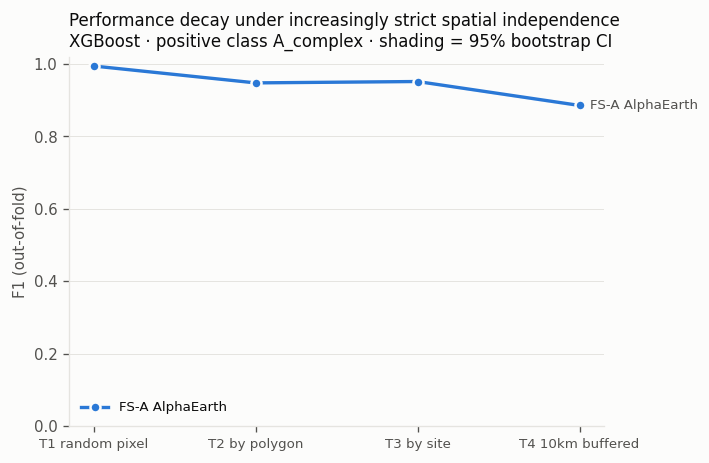

In [27]:
# ============================================================
# 9. Figure - the leakage ladder (the single most important figure)
# ============================================================
# Line plot: x = spatial independence tightened one tier at a time, y = F1.
# Three lines = three feature sets, exactly filling the three safe colour slots.
POSDEF_TO_PLOT = 'A_complex'
MODEL_TO_PLOT  = 'XGBoost'

sub = results[(results.positive_def==POSDEF_TO_PLOT) &
              (results.model==MODEL_TO_PLOT)]

fig, ax = plt.subplots(figsize=(6.6, 4.0))
x = np.arange(len(SPLIT_ORDER))
for i,(fs, g) in enumerate(sub.groupby('feature_set')):
    g = g.set_index('split').reindex(SPLIT_ORDER)
    c = PAL['series'][i]
    ax.fill_between(x, g['f1_lo'], g['f1_hi'], color=c, alpha=0.12, linewidth=0)
    ax.plot(x, g['f1'], color=c, marker='o', markeredgecolor=PAL['surface'],
            markeredgewidth=1.5, label=fs, zorder=3)
    # Label the line ends directly, so identity does not rest on colour alone
    ax.annotate(fs, (x[-1], g['f1'].iloc[-1]), xytext=(6,0),
                textcoords='offset points', va='center',
                fontsize=8, color=PAL['ink2'])

ax.set_xticks(x); ax.set_xticklabels(SPLIT_ORDER, fontsize=8)
ax.set_ylabel('F1 (out-of-fold)'); ax.set_ylim(0,1.02)
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.set_title(f'Performance decay under increasingly strict spatial independence\n'
             f'{MODEL_TO_PLOT} · positive class {POSDEF_TO_PLOT} · shading = 95% bootstrap CI',
             loc='left', color=PAL['ink'])
ax.legend(loc='lower left', fontsize=8)
fig.subplots_adjust(right=0.80)
save_fig(fig,'F5_3_leakage_ladder'); plt.show()

In [28]:
# ============================================================
# 10. Per-country behaviour inside the training pool
# ============================================================
# T4 holds out whole sites and drops every training site within 10 km of them, so the
# scores below are out-of-fold: each country is scored by a model that did not see the
# sites being scored. This is the in-domain counterpart of the T5/T6 table later on,
# and it is where a country that the representation handles badly becomes visible.
fs  = 'FS-A AlphaEarth'
T4  = SPLIT_ORDER[-1]
r4  = results[(results.positive_def == POSDEF_TO_PLOT) & (results.feature_set == fs) &
              (results.model == MODEL_TO_PLOT) & (results.split == T4)].iloc[0]
thr, PI = float(r4.threshold), float(r4.prevalence)

print('='*74)
print('A.  The ladder, T1 to T4')
print('='*74)
lad = (results[(results.positive_def == POSDEF_TO_PLOT) & (results.feature_set == fs) &
               (results.model == MODEL_TO_PLOT)].set_index('split')
       .reindex(SPLIT_ORDER)[['f1','f1_lo','f1_hi','pr_auc','threshold','prevalence']])
print(lad.round(3).to_string())
print(f'\nLeakage gap T1 -> T4: '
      f'{lad.loc[SPLIT_ORDER[0],"f1"] - lad.loc[T4,"f1"]:+.3f}')
print(f'Decision threshold fixed at T4: {thr:.4f}')
print('  This threshold is used unchanged at T5 and T6 below, and is the value')
print('  ASGM_02_predict_map.ipynb must read when the map is produced.')

d_tr, oof = oof_store[(POSDEF_TO_PLOT, fs, MODEL_TO_PLOT, T4)]
ok  = ~np.isnan(oof)
dd  = d_tr[ok].copy(); dd['_p'] = oof[ok]

print('\n' + '='*74)
print('B.  T4 out-of-fold performance, country by country (prevalence matched)')
print('='*74)
rows = []
for iso, g0 in dd.groupby('country_iso3'):
    if g0['y'].nunique() < 2: continue
    g = match_prevalence(g0, PI)
    m = metrics_at(g['y'].values, g['_p'].values, thr)
    rows.append({'country': iso,
                 'n_labelled_px': int((train_c.country_iso3 == iso).sum()),
                 **{k: m[k] for k in
                    ['n_eval','precision','recall','f1','f1_lo','f1_hi','pr_auc']}})
t4c = pd.DataFrame(rows).set_index('country').sort_values('f1')
print(t4c.round(3).to_string())
print(f'\n  Spread across training countries: '
      f'{t4c.f1.min():.3f} ({t4c.f1.idxmin()}) to {t4c.f1.max():.3f} ({t4c.f1.idxmax()})')
print('  A country well below the rest is a finding, not a nuisance: it shows that')
print('  difficulty is country-specific rather than a simple in-domain / out-of-domain')
print('  divide. Report the spread, not only the pooled T4 value.')

print('\n' + '='*74)
print('C.  Label quality check - polygons the model rejects from inside its own')
print('    training distribution')
print('='*74)
# A positive polygon that is scored near zero OUT OF FOLD, while its neighbours in the
# same country are scored near one, is a candidate labelling error. This is the cheapest
# label-audit available and it costs nothing to run.
pos = dd[dd.y == 1]
pp = (pos.groupby(['country_iso3', 'polygon_id'])
        .agg(n_px=('_p', 'size'), mean_p=('_p', 'mean'),
             frac_above=('_p', lambda v: (v >= thr).mean())).reset_index())
susp = pp[pp.frac_above < 0.10].sort_values('mean_p')
print(f'{len(susp)} of {len(pp)} positive polygons have under 10% of their pixels '
      f'above the threshold:')
if len(susp):
    print(susp.round(3).to_string(index=False))
    print('\n  Inspect these in GEE with the SWIR composite before the final run.')
    print('  A polygon at mean_p < 0.05 while the rest of its country sits near 1.0 is')
    print('  far more likely to be mislabelled than to be a genuinely unusual mine.')

lad.to_csv(OUT_DIR / 'table_5_2_ladder.csv')
t4c.to_csv(OUT_DIR / 'table_5_3_t4_by_country.csv')
susp.to_csv(OUT_DIR / 'table_B1_suspect_polygons.csv', index=False)
print('\nsaved table_5_2_ladder.csv, table_5_3_t4_by_country.csv, '
      'table_B1_suspect_polygons.csv')

A.  The ladder, T1 to T4
                     f1  f1_lo  f1_hi  pr_auc  threshold  prevalence
split                                                               
T1 random pixel   0.994  0.993  0.995   1.000      0.503       0.414
T2 by polygon     0.948  0.945  0.951   0.983      0.736       0.414
T3 by site        0.952  0.949  0.954   0.985      0.470       0.414
T4 10km buffered  0.886  0.882  0.889   0.950      0.541       0.414

Leakage gap T1 -> T4: +0.109
Decision threshold fixed at T4: 0.5406
  This threshold is used unchanged at T5 and T6 below, and is the value
  ASGM_02_predict_map.ipynb must read when the map is produced.

B.  T4 out-of-fold performance, country by country (prevalence matched)
         n_labelled_px  n_eval  precision  recall     f1  f1_lo  f1_hi  pr_auc
country                                                                       
COL               8032    6002      0.889   0.502  0.641  0.625  0.659   0.829
ECU               4050    3461      0.999   0.

15,000 pixels sampled from 35,275  (41.3% positive, 9 labelled classes)

1.  Variance retained by a two-dimensional view
  PC1 23.1%   PC2 16.0%   PC1+PC2 39.0%
  first  5 components: 67.8%
  first 10 components: 81.9%
  first 20 components: 92.3%
  first 40 components: 98.7%
  components needed for 90% of the variance: 17
  -> a 2-D scatter is a small slice of this space, and class overlap seen
     in it is not evidence of overlap in the space the model actually uses.

fitting UMAP (this takes 1-2 minutes)...

2.  How much class structure survives the projection?
  5-NN binary agreement, 3-fold, identical rows in every row of the table
                   space  dims  knn_f1
     full 64-D embedding    64   0.990
 PCA, first 2 components     2   0.771
      UMAP, 2 components     2   0.985
PCA, first 10 components    10   0.980

  Full space 0.990 against 2-D PCA 0.771: the projection loses 0.219.
  Read alongside the T4 logistic-regression result: a linear boundary in the
  full spac

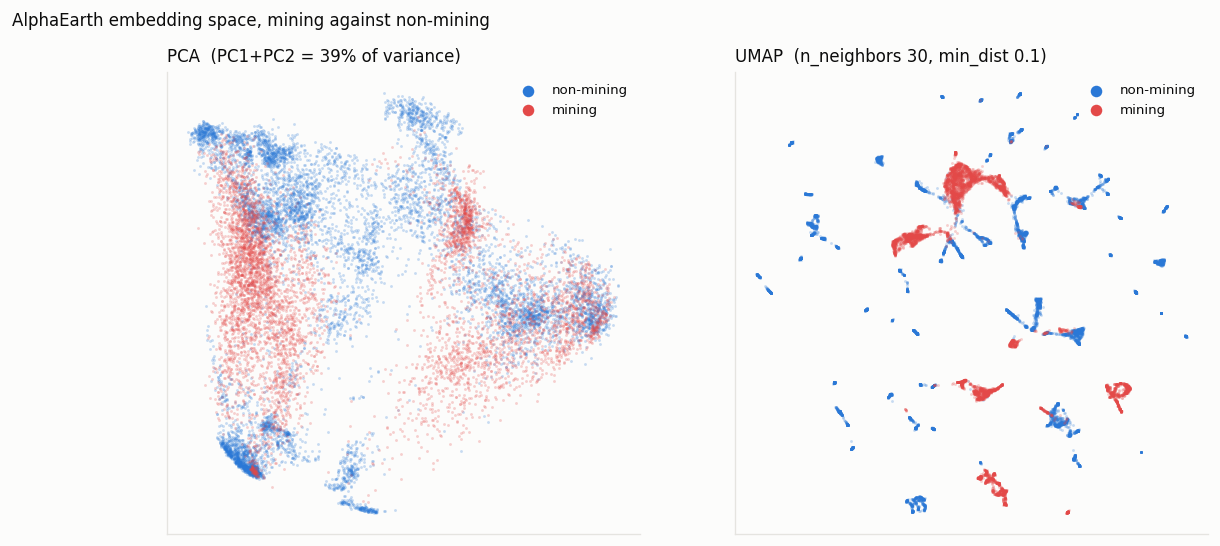

saved: F5_2_embedding_facets_final


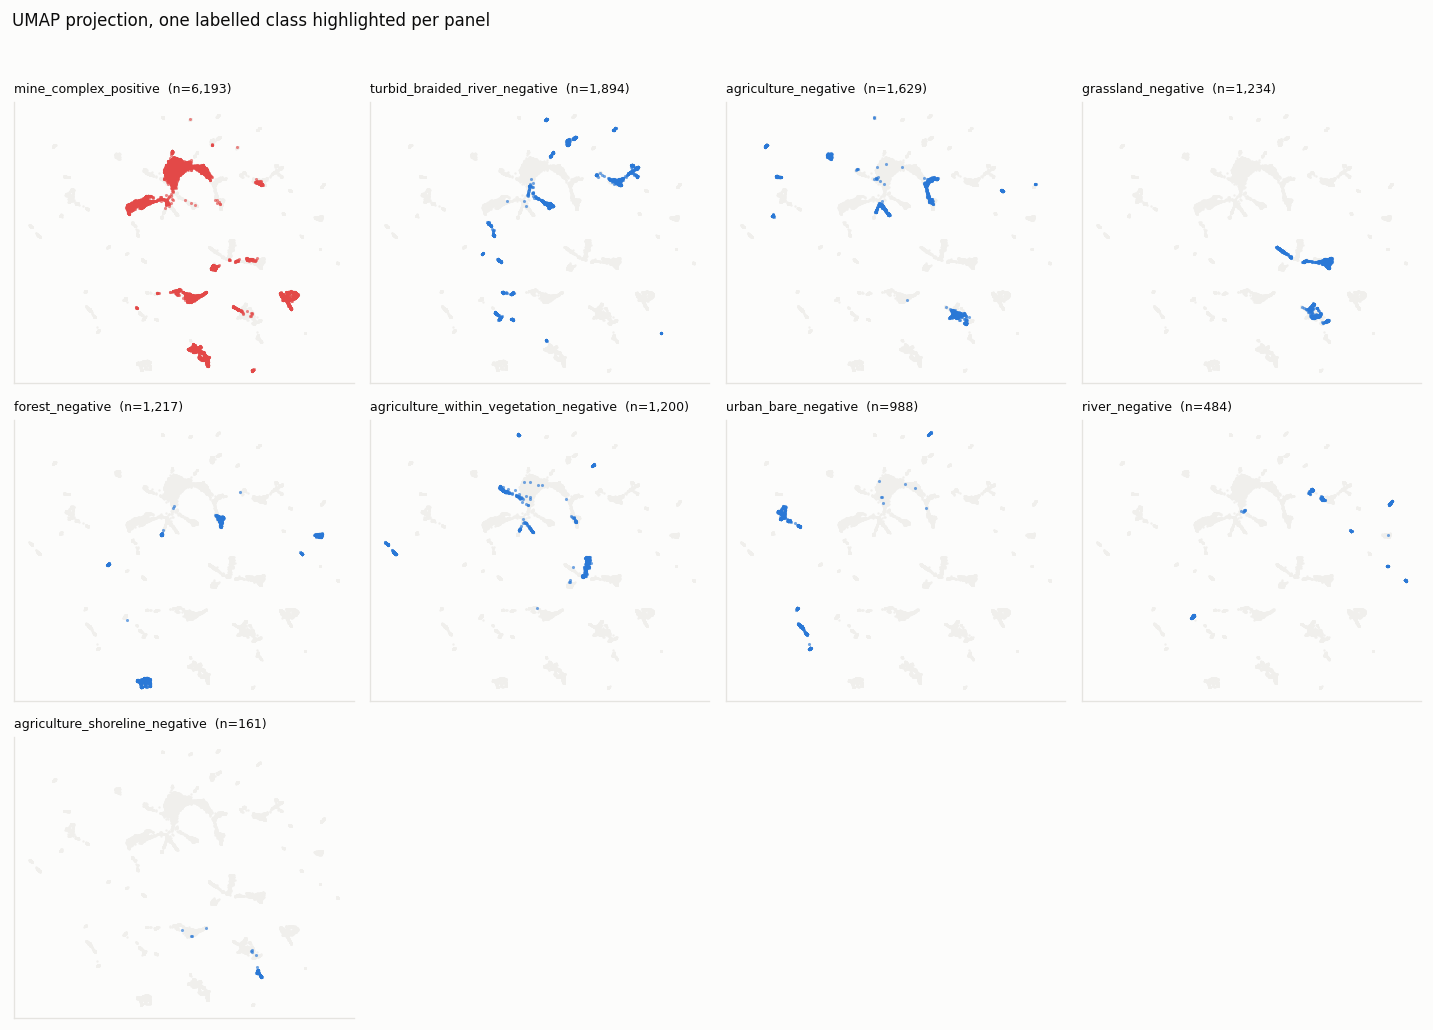


saved table_5_1_pca_variance.csv, table_5_1b_separability_by_space.csv


In [36]:
# ============================================================
# 10b. Embedding-space structure: PCA, UMAP, and how much 2-D hides
# ============================================================
# Supervisory note (Meeting 4): the 64-dimensional AlphaEarth space was to be
# inspected in two dimensions to see where the classes overlap. The observation
# then was that mining "is fairly localized in one corner of the embedding space",
# and that the classes "would be separated even more along the other axes".
#
# That second half is testable rather than imaginable, so this cell does both:
# it produces the two projections, and it MEASURES how much separability a
# two-dimensional view throws away. Reporting the projections without that
# measurement invites the reader to judge separability from a picture that, as
# shown below, retains only a minority of the variance.
import warnings
warnings.filterwarnings('ignore')
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

try:
    import umap
    HAVE_UMAP = True
except Exception:
    try:
        import subprocess, sys
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'umap-learn'])
        import umap
        HAVE_UMAP = True
    except Exception as e:
        print('umap-learn unavailable, PCA only:', e)
        HAVE_UMAP = False

A = list(ALPHA)
d = make_dataset(train_c, POSDEF_TO_PLOT).reset_index(drop=True)
N_VIS = 15000
samp = d.sample(min(N_VIS, len(d)), random_state=RANDOM_SEED).reset_index(drop=True)
X = samp[A].values
y = samp['y'].values
lab = samp['label'].astype(str).values
print(f'{len(samp):,} pixels sampled from {len(d):,}  '
      f'({y.mean():.1%} positive, {samp.label.nunique()} labelled classes)')

# ---- 1. how much does two dimensions actually retain? ----------------------
pca_full = PCA(n_components=min(64, X.shape[1]), random_state=RANDOM_SEED).fit(X)
ev = pca_full.explained_variance_ratio_
print('\n' + '='*70)
print('1.  Variance retained by a two-dimensional view')
print('='*70)
print(f'  PC1 {ev[0]:.1%}   PC2 {ev[1]:.1%}   PC1+PC2 {ev[:2].sum():.1%}')
for k in (5, 10, 20, 40):
    if k <= len(ev):
        print(f'  first {k:2d} components: {ev[:k].sum():.1%}')
n90 = int(np.searchsorted(np.cumsum(ev), 0.90) + 1)
print(f'  components needed for 90% of the variance: {n90}')
print('  -> a 2-D scatter is a small slice of this space, and class overlap seen')
print('     in it is not evidence of overlap in the space the model actually uses.')

Z_pca = pca_full.transform(X)[:, :2]

if HAVE_UMAP:
    print('\nfitting UMAP (this takes 1-2 minutes)...')
    Z_umap = umap.UMAP(n_neighbors=30, min_dist=0.1, n_components=2,
                       metric='euclidean', random_state=RANDOM_SEED).fit_transform(X)
else:
    Z_umap = None

# ---- 2. separability in 64-D against separability in each projection -------
# 5-nearest-neighbour class agreement, 3-fold. Not a performance estimate - the
# folds are not spatially blocked - but a like-for-like comparison of how much
# class structure survives each projection.
print('\n' + '='*70)
print('2.  How much class structure survives the projection?')
print('='*70)
print('  5-NN binary agreement, 3-fold, identical rows in every row of the table')
def knn_score(Xa):
    return cross_val_score(KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
                           Xa, y, cv=3, scoring='f1').mean()
rows = [('full 64-D embedding', 64, knn_score(X)),
        ('PCA, first 2 components', 2, knn_score(Z_pca))]
if Z_umap is not None:
    rows.append(('UMAP, 2 components', 2, knn_score(Z_umap)))
rows.append(('PCA, first 10 components', 10, knn_score(pca_full.transform(X)[:, :10])))
sep = pd.DataFrame(rows, columns=['space', 'dims', 'knn_f1']).round(3)
print(sep.to_string(index=False))
print(f"\n  Full space {sep.knn_f1.iloc[0]:.3f} against 2-D PCA {sep.knn_f1.iloc[1]:.3f}: "
      f"the projection loses {sep.knn_f1.iloc[0] - sep.knn_f1.iloc[1]:.3f}.")
print('  Read alongside the T4 logistic-regression result: a linear boundary in the')
print('  full space reaches most of what gradient boosting reaches, so the classes')
print('  are close to linearly separable there even where a 2-D plot looks mixed.')

# ---- 3. figures ------------------------------------------------------------
def scatter_binary(ax, Z, title):
    for cls, col, name in [(0, PAL['neg'], 'non-mining'), (1, PAL['pos'], 'mining')]:
        m = y == cls
        ax.scatter(Z[m, 0], Z[m, 1], s=3, c=col, alpha=0.25, linewidths=0, label=name)
    ax.set_title(title, loc='left')
    ax.set_xticks([]); ax.set_yticks([])
    lg = ax.legend(fontsize=8, loc='upper right', markerscale=4)
    for h in lg.legend_handles: h.set_alpha(1.0)

ncol = 2 if Z_umap is not None else 1
fig, axes = plt.subplots(1, ncol, figsize=(5.6*ncol, 5.0), squeeze=False)
scatter_binary(axes[0][0], Z_pca,
               f'PCA  (PC1+PC2 = {ev[:2].sum():.0%} of variance)')
if Z_umap is not None:
    scatter_binary(axes[0][1], Z_umap, 'UMAP  (n_neighbors 30, min_dist 0.1)')
fig.suptitle('AlphaEarth embedding space, mining against non-mining',
             x=0.01, ha='left', fontsize=10)
save_fig(fig, 'F5_1_embedding_2d'); plt.show()

# Per-class facets: a scatter needs every pair of classes to be separable and the
# palette guarantees only three slots, so classes are faceted rather than coloured.
classes = [c for c in samp.label.value_counts().index]
Zf, zname = (Z_umap, 'UMAP') if Z_umap is not None else (Z_pca, 'PCA')
ncols = 4
nrows = int(np.ceil(len(classes)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.0*ncols, 2.9*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, cls in zip(axes, classes):
    m = lab == cls
    ax.scatter(Zf[~m, 0], Zf[~m, 1], s=2, c=PAL['neutral'], linewidths=0)
    col = PAL['pos'] if 'positive' in cls else PAL['neg']
    ax.scatter(Zf[m, 0], Zf[m, 1], s=3.5, c=col, alpha=0.65, linewidths=0)
    ax.set_title(f'{cls}  (n={int(m.sum()):,})', fontsize=7.5, loc='left')
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes[len(classes):]: ax.axis('off')
fig.suptitle(f'{zname} projection, one labelled class highlighted per panel',
             x=0.01, ha='left', fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.96])
save_fig(fig, 'F5_2_embedding_facets'); plt.show()

pd.DataFrame({'component': np.arange(1, len(ev)+1),
              'explained_variance_ratio': ev,
              'cumulative': np.cumsum(ev)}).to_csv(
    OUT_DIR/'table_5_1_pca_variance.csv', index=False)
sep.to_csv(OUT_DIR/'table_5_1b_separability_by_space.csv', index=False)
print('\nsaved table_5_1_pca_variance.csv, table_5_1b_separability_by_space.csv')


In [29]:
# ============================================================
# 11. Summary table and gap computation
# ============================================================
piv = (results[results.positive_def==POSDEF_TO_PLOT]
       .pivot_table(index=['feature_set','model'], columns='split', values='f1')
       .reindex(columns=SPLIT_ORDER))
print(f'F1 summary (positive class {POSDEF_TO_PLOT})'); display(piv.round(3))

print('\n* Key gaps (these are what the dissertation reports, not single F1 values)')
for fs in FEATURE_SETS:
    r = results[(results.positive_def==POSDEF_TO_PLOT)&(results.model==MODEL_TO_PLOT)&
                (results.feature_set==fs)].set_index('split')
    if SPLIT_ORDER[0] in r.index and SPLIT_ORDER[-1] in r.index:
        print(f'  {fs:18s} leakage gap T1->T4 = {r.loc[SPLIT_ORDER[0],"f1"]-r.loc[SPLIT_ORDER[-1],"f1"]:+.3f}')

a = results[(results.positive_def==POSDEF_TO_PLOT)&(results.model==MODEL_TO_PLOT)&
            (results.feature_set=='FS-A AlphaEarth')&(results.split==SPLIT_ORDER[-1])]
b = results[(results.positive_def==POSDEF_TO_PLOT)&(results.model==MODEL_TO_PLOT)&
            (results.feature_set=='FS-B Sentinel-2')&(results.split==SPLIT_ORDER[-1])]
if len(a) and len(b):
    print(f'\n  AlphaEarth gain over Sentinel-2 (strictest split) = {a.f1.iloc[0]-b.f1.iloc[0]:+.3f}')

piv.to_csv(OUT_DIR/'table_5_1_f1_summary.csv')
print('\nAll results and figures saved to:', OUT_DIR)

F1 summary (positive class A_complex)


split                    T1 random pixel  T2 by polygon  T3 by site  \
feature_set     model                                                 
FS-A AlphaEarth LogReg             0.947          0.914       0.895   
                RF                 0.983          0.939       0.939   
                XGBoost            0.994          0.948       0.952   

split                    T4 10km buffered  
feature_set     model                      
FS-A AlphaEarth LogReg              0.856  
                RF                  0.864  
                XGBoost             0.886


* Key gaps (these are what the dissertation reports, not single F1 values)
  FS-A AlphaEarth    leakage gap T1->T4 = +0.109

All results and figures saved to: /content/drive/MyDrive/dissertation/results_classification_transfer


In [30]:
# ============================================================
# 12. T5 / T6 - load the held-out test countries
# ============================================================
# Fixed allocation used in the final analysis:
#   Training countries: BRA PER COL GUY ECU
#   Held-out countries: BOL VEN GUF SUR      (cross-country)
#                       GHA IDN MMR          (cross-continent)
print('Resolving held-out files by exact name:')
test_files = resolve_test_files()
for iso, q in sorted(test_files.items()):
    print(f'  {iso}  {q.name}')
assert 'ECU' not in test_files, 'ECU must not be a held-out country in this experiment'

if not test_files:
    print('No held-out files - T5/T6 will be skipped.')
    test_c = None
else:
    frames = []
    for iso, q in sorted(test_files.items()):
        f = pd.read_csv(q)
        print(f'  {q.name}: {len(f):,} rows')
        frames.append(f)
    test = pd.concat(frames, ignore_index=True)

    # ---- identical QC to the training table -------------------------------
    n0 = len(test)
    test = test.dropna(subset=ALPHA).copy()
    test['_gx'] = (test['longitude']*1e4).round().astype(int)
    test['_gy'] = (test['latitude'] *1e4).round().astype(int)
    dup = test.duplicated(subset=['_gx','_gy']).sum()
    test = test.drop_duplicates(subset=['_gx','_gy']).reset_index(drop=True)
    print(f'\nQC: {n0:,} -> {len(test):,} rows  (duplicates removed: {dup:,})')

    test_c = cap_per_polygon(test).reset_index(drop=True)
    print(f'After per-polygon cap ({MAX_PIXELS_PER_POLYGON}): {len(test_c):,} rows')

    print('\nBy country x class:')
    print(test_c.groupby(['country_iso3','binary']).size().to_string())
    assert 'ECU' not in set(test_c['country_iso3']), (
        'ECU rows reached the held-out table. The files were resolved by name, so '
        'this means an ECU row is stored inside another country\'s csv.')
    print('\nBy tier:'); print(test_c['tier'].value_counts().to_string())
    print('\nBy label:'); print(test_c['label'].value_counts().to_string())
    print('\nDistinct polygons:', test_c['polygon_id'].nunique(),
          ' distinct sites:', test_c['site_id'].nunique())

Resolving held-out files by exact name:
  BOL  sa9_v8_test_2024_fast_BOL.csv
  GHA  sa9_v8_test_2024_fast_GHA.csv
  GUF  sa9_v8_test_2024_fast_GUF.csv
  IDN  sa9_v8_test_2024_fast_IDN.csv
  MMR  sa9_v8_test_2024_fast_MMR.csv
  SUR  sa9_v8_test_2024_fast_SUR.csv
  VEN  sa9_v8_test_2024_fast_VEN.csv
  sa9_v8_test_2024_fast_BOL.csv: 4,924 rows
  sa9_v8_test_2024_fast_GHA.csv: 5,884 rows
  sa9_v8_test_2024_fast_GUF.csv: 4,520 rows
  sa9_v8_test_2024_fast_IDN.csv: 5,441 rows
  sa9_v8_test_2024_fast_MMR.csv: 6,214 rows
  sa9_v8_test_2024_fast_SUR.csv: 6,265 rows
  sa9_v8_test_2024_fast_VEN.csv: 5,590 rows

QC: 38,838 -> 35,088 rows  (duplicates removed: 3,750)
After per-polygon cap (300): 34,920 rows

By country x class:
country_iso3  binary
BOL           0         1298
              1         3021
GHA           0         2041
              1         3112
GUF           0         1278
              1         2735
IDN           0         2574
              1         2508
MMR           0       

In [31]:
# ============================================================
# 13. T5 / T6 - held-out evaluation at the T4 threshold
# ============================================================
# Three rules make T5/T6 comparable with T1-T4:
#   (i)   the model, features and hyper-parameters are unchanged;
#   (ii)  the decision threshold is the one fixed on T4 and is NEVER re-tuned here;
#   (iii) the positive-class prevalence of each test country is matched to the
#         prevalence of the T1-T4 evaluation, because F1 is prevalence-dependent
#         and an unmatched test set would change F1 without the model changing.
TARGET_PREVALENCE = None      # None -> take it from the T4 row of results_grid

def get_t4_row(posdef, feature_set, model_name):
    r = results[(results.positive_def == posdef) &
                (results.feature_set == feature_set) &
                (results.model == model_name) &
                (results.split.astype(str).str.startswith('T4'))]
    if len(r) != 1:
        raise ValueError(f'Expected 1 T4 row, found {len(r)}')
    return r.iloc[0]

# match_prevalence() and metrics_at() are defined in the models cell above.

transfer_rows, transfer_oof = [], {}

if test_c is not None:
    for posdef in POSITIVE_DEFS:
        d_tr = make_dataset(train_c, posdef).reset_index(drop=True)
        d_te_all = make_dataset(test_c, posdef).reset_index(drop=True)
        if d_te_all['y'].nunique() < 2:
            print(f'{posdef}: test set has a single class, skipped'); continue

        for fs_name, feats in FEATURE_SETS.items():
            for model_name in MODELS:
                t4 = get_t4_row(posdef, fs_name, model_name)
                thr = float(t4.threshold)
                target = TARGET_PREVALENCE if TARGET_PREVALENCE else float(t4.prevalence)

                # fit ONCE on every training row; this is a hold-out, not a CV
                m = make_model(model_name, d_tr['y'].values)
                m.fit(d_tr[feats].values, d_tr['y'].values)
                p_all = m.predict_proba(d_te_all[feats].values)[:, 1]
                d_te_all = d_te_all.assign(_p=p_all)
                transfer_oof[(posdef, fs_name, model_name)] = (d_te_all.copy(), p_all)

                for tier in sorted(d_te_all['tier'].dropna().unique()):
                    d_t = d_te_all[d_te_all['tier'] == tier]
                    if d_t['y'].nunique() < 2: continue

                    raw = metrics_at(d_t['y'].values, d_t['_p'].values, thr)
                    d_m = match_prevalence(d_t, target)
                    mat = metrics_at(d_m['y'].values, d_m['_p'].values, thr)

                    transfer_rows.append({
                        'positive_def': posdef, 'feature_set': fs_name,
                        'model': model_name, 'split': tier, 'scope': 'ALL',
                        'threshold': thr, 'target_prevalence': target,
                        **{f'raw_{k}': v for k, v in raw.items()}, **mat})

                    # per-country breakdown (Section 5.4 / 5.5)
                    for iso in sorted(d_t['country_iso3'].unique()):
                        d_ci = d_t[d_t['country_iso3'] == iso]
                        if d_ci['y'].nunique() < 2: continue
                        d_cm = match_prevalence(d_ci, target)
                        cm = metrics_at(d_cm['y'].values, d_cm['_p'].values, thr)
                        transfer_rows.append({
                            'positive_def': posdef, 'feature_set': fs_name,
                            'model': model_name, 'split': tier, 'scope': iso,
                            'threshold': thr, 'target_prevalence': target,
                            **{f'raw_{k}': np.nan for k in raw}, **cm})

    transfer = pd.DataFrame(transfer_rows)
    transfer.to_csv(OUT_DIR/'results_transfer.csv', index=False)

    key = ((transfer.positive_def == POSDEF_TO_PLOT) &
           (transfer.feature_set == 'FS-A AlphaEarth') &
           (transfer.model == MODEL_TO_PLOT))
    print('\n=== Transfer results:', MODEL_TO_PLOT, '|', POSDEF_TO_PLOT, '===')
    print(transfer[key & (transfer.scope == 'ALL')][
        ['split','n_eval','prevalence','raw_prevalence','precision','recall',
         'f1','f1_lo','f1_hi']].round(3).to_string(index=False))
    print('\nBy country (prevalence-matched):')
    print(transfer[key & (transfer.scope != 'ALL')][
        ['split','scope','n_eval','precision','recall','f1','f1_lo','f1_hi']
        ].round(3).to_string(index=False))

    t4f1 = float(get_t4_row(POSDEF_TO_PLOT, 'FS-A AlphaEarth', MODEL_TO_PLOT).f1)
    for _, r in transfer[key & (transfer.scope == 'ALL')].iterrows():
        print(f"\n* {r.split}: F1 {r.f1:.3f}  vs T4 {t4f1:.3f}  "
              f"-> transfer gap {r.f1 - t4f1:+.3f}")
else:
    transfer = pd.DataFrame()
    print('No test data - T5/T6 skipped.')


=== Transfer results: XGBoost | A_complex ===
split  n_eval  prevalence  raw_prevalence  precision  recall    f1  f1_lo  f1_hi
   T5   11669       0.413            0.52      0.753   0.931 0.833  0.826   0.84
   T6   11586       0.414            0.47      0.867   0.880 0.873  0.867   0.88

By country (prevalence-matched):
split scope  n_eval  precision  recall    f1  f1_lo  f1_hi
   T5   BOL    2213      0.723   0.967 0.827  0.810  0.845
   T5   GUF    2179      0.860   0.835 0.847  0.829  0.865
   T5   SUR    4713      0.771   0.954 0.853  0.841  0.862
   T5   VEN    2564      0.688   0.952 0.799  0.782  0.816
   T6   GHA    3480      0.961   0.830 0.891  0.879  0.901
   T6   IDN    4389      0.956   0.953 0.954  0.948  0.961
   T6   MMR    3717      0.714   0.841 0.772  0.755  0.788

* T5: F1 0.833  vs T4 0.886  -> transfer gap -0.053

* T6: F1 0.873  vs T4 0.886  -> transfer gap -0.012


saved: F5_3b_full_ladder_T1_T6_final


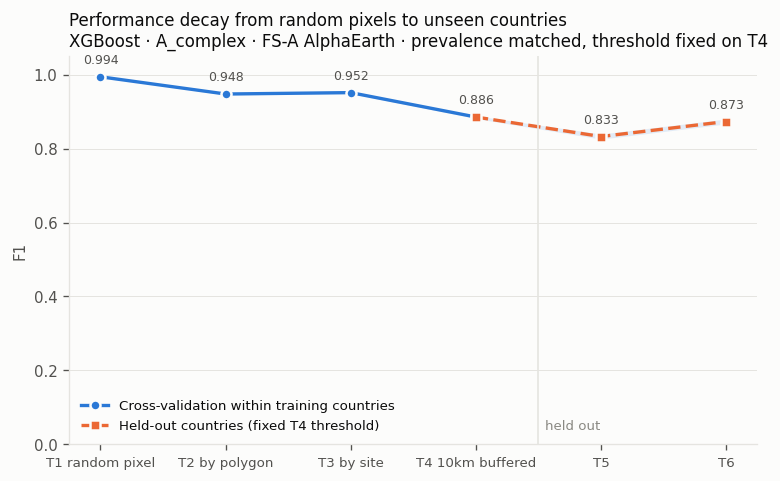

saved: F5_6_transfer_by_country_final


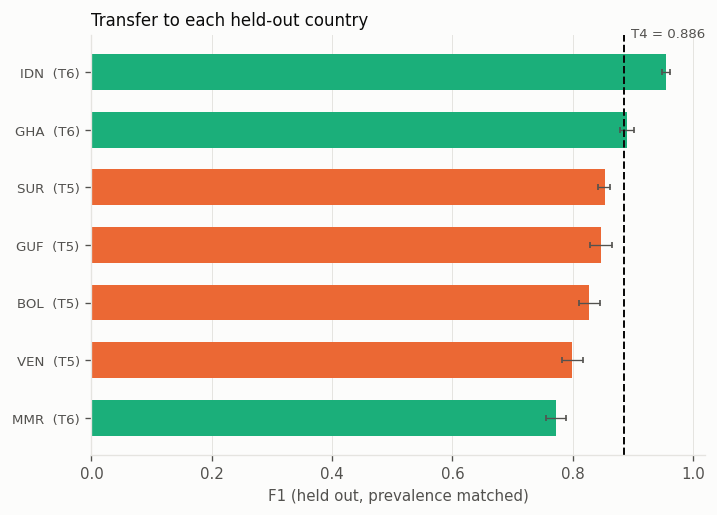

,split,n_eval,prevalence,precision,recall,f1,f1_lo,f1_hi
18,T5,11669,0.413,0.753,0.931,0.833,0.826,0.84
23,T6,11586,0.414,0.867,0.880,0.873,0.867,0.88


In [32]:
# ============================================================
# 14. Figure - the full ladder, T1 to T6
# ============================================================
if len(transfer):
    k = ((transfer.positive_def == POSDEF_TO_PLOT) &
         (transfer.feature_set == 'FS-A AlphaEarth') &
         (transfer.model == MODEL_TO_PLOT) & (transfer.scope == 'ALL'))
    tr_all = transfer[k].set_index('split')

    base = results[(results.positive_def == POSDEF_TO_PLOT) &
                   (results.feature_set == 'FS-A AlphaEarth') &
                   (results.model == MODEL_TO_PLOT)].set_index('split').reindex(SPLIT_ORDER)

    order = list(SPLIT_ORDER) + [s for s in ['T5','T6'] if s in tr_all.index]
    f1s = list(base['f1']) + [tr_all.loc[s,'f1'] for s in order[len(SPLIT_ORDER):]]
    los = list(base['f1_lo']) + [tr_all.loc[s,'f1_lo'] for s in order[len(SPLIT_ORDER):]]
    his = list(base['f1_hi']) + [tr_all.loc[s,'f1_hi'] for s in order[len(SPLIT_ORDER):]]

    fig, ax = plt.subplots(figsize=(7.4, 4.2))
    x = np.arange(len(order))
    n_cv = len(SPLIT_ORDER)
    ax.fill_between(x, los, his, color=PAL['series'][0], alpha=0.12, linewidth=0)
    ax.plot(x[:n_cv], f1s[:n_cv], color=PAL['series'][0], marker='o',
            markeredgecolor=PAL['surface'], markeredgewidth=1.5,
            label='Cross-validation within training countries')
    ax.plot(x[n_cv-1:], f1s[n_cv-1:], color=PAL['series'][1], marker='s', ls='--',
            markeredgecolor=PAL['surface'], markeredgewidth=1.5,
            label='Held-out countries (fixed T4 threshold)')
    ax.axvline(n_cv-0.5, color=PAL['grid'], lw=1)
    ax.annotate('held out', (n_cv-0.45, 0.04), fontsize=8, color=PAL['muted'])
    for xi, v in zip(x, f1s):
        ax.annotate(f'{v:.3f}', (xi, v), xytext=(0, 8), textcoords='offset points',
                    ha='center', fontsize=7.5, color=PAL['ink2'])
    ax.set_xticks(x); ax.set_xticklabels(order, fontsize=8)
    ax.set_ylabel('F1'); ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.set_title('Performance decay from random pixels to unseen countries\n'
                 f'{MODEL_TO_PLOT} · {POSDEF_TO_PLOT} · FS-A AlphaEarth · '
                 'prevalence matched, threshold fixed on T4', loc='left')
    ax.legend(fontsize=8, loc='lower left')
    save_fig(fig, 'F5_3b_full_ladder_T1_T6'); plt.show()

    # ---- per-country transfer -------------------------------------------
    kc = ((transfer.positive_def == POSDEF_TO_PLOT) &
          (transfer.feature_set == 'FS-A AlphaEarth') &
          (transfer.model == MODEL_TO_PLOT) & (transfer.scope != 'ALL'))
    cc = transfer[kc].sort_values('f1')
    if len(cc):
        fig, ax = plt.subplots(figsize=(6.6, 0.42*len(cc)+1.6))
        y = np.arange(len(cc))
        colors = [PAL['series'][1] if s == 'T5' else PAL['series'][2]
                  for s in cc['split']]
        ax.barh(y, cc['f1'], color=colors, height=0.62)
        ax.errorbar(cc['f1'], y, xerr=[cc['f1']-cc['f1_lo'], cc['f1_hi']-cc['f1']],
                    fmt='none', ecolor=PAL['ink2'], elinewidth=0.8, capsize=2)
        t4f1 = float(get_t4_row(POSDEF_TO_PLOT, 'FS-A AlphaEarth', MODEL_TO_PLOT).f1)
        ax.axvline(t4f1, color=PAL['ink'], ls='--', lw=1.2)
        ax.annotate(f'T4 = {t4f1:.3f}', (t4f1, len(cc)-0.4), xytext=(4, 0),
                    textcoords='offset points', fontsize=8, color=PAL['ink2'])
        ax.set_yticks(y)
        ax.set_yticklabels([f'{r.scope}  ({r.split})' for _, r in cc.iterrows()],
                           fontsize=8)
        ax.set_xlabel('F1 (held out, prevalence matched)')
        ax.set_xlim(0, 1.02); ax.xaxis.grid(True); ax.set_axisbelow(True)
        ax.set_title('Transfer to each held-out country', loc='left')
        save_fig(fig, 'F5_6_transfer_by_country'); plt.show()

    display(transfer[k][['split','n_eval','prevalence','precision','recall',
                         'f1','f1_lo','f1_hi']].round(3))
else:
    print('No transfer results to plot.')

Fixed threshold from T4 = 0.5406   target prevalence = 0.414
T4 reference: PR-AUC 0.950   F1 0.886

tier scope     n  PR_AUC  F1_fixed_thr  F1_oracle_thr  oracle_thr  mean_prob_pos  mean_prob_neg  recoverable
  T5   ALL 11669   0.942         0.833          0.844       0.900          0.913          0.245        0.011
  T5   BOL  2213   0.967         0.827          0.896       0.893          0.940          0.245        0.068
  T5   GUF  2179   0.934         0.847          0.851       0.645          0.825          0.163        0.004
  T5   SUR  4713   0.947         0.853          0.854       0.510          0.931          0.221        0.002
  T5   VEN  2564   0.944         0.799          0.863       0.967          0.940          0.357        0.064
  T6   ALL 11586   0.950         0.873          0.874       0.564          0.855          0.151        0.001
  T6   GHA  3480   0.967         0.891          0.940       0.219          0.818          0.055        0.049
  T6   IDN  4389   0.982    

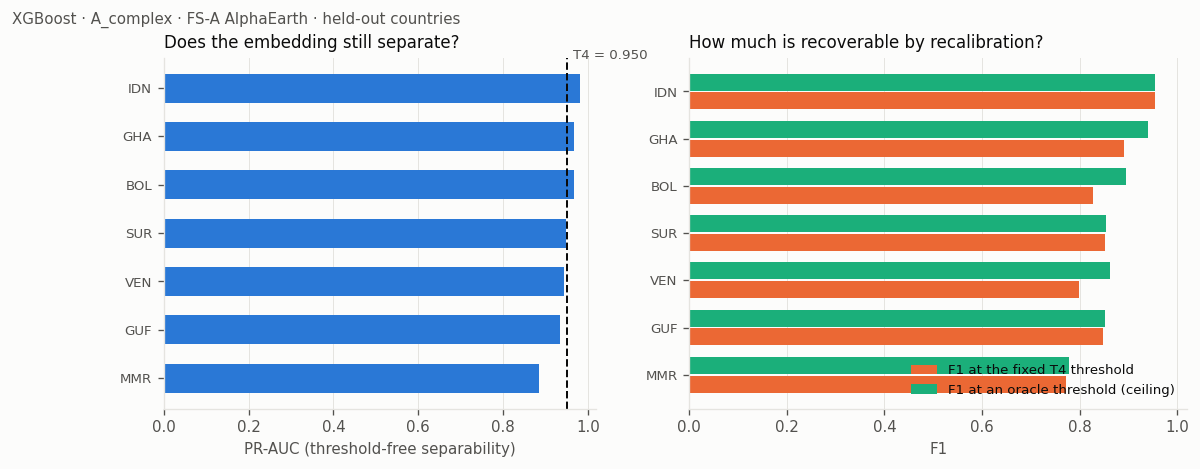

In [33]:
# ============================================================
# 15. Diagnostic - is the representation failing, or only the threshold?
# ============================================================
# A drop in F1 at a fixed threshold can come from two very different causes:
#   (a) the embedding no longer separates mining from non-mining in the new
#       country  -> PR-AUC falls too, and recalibration cannot help;
#   (b) the classes are still separable but the decision boundary has shifted
#       -> PR-AUC stays high and an oracle threshold recovers most of the loss.
# Only (a) is a failure of transfer in the strong sense.
#
# The oracle threshold is a DIAGNOSTIC CEILING, not a reportable operating point:
# it is chosen on the test labels and could not be known before deployment.
if len(transfer):
    posdef, fs = POSDEF_TO_PLOT, 'FS-A AlphaEarth'
    d_te, _ = transfer_oof[(posdef, fs, MODEL_TO_PLOT)]
    t4 = get_t4_row(posdef, fs, MODEL_TO_PLOT)
    thr, target = float(t4.threshold), float(t4.prevalence)

    rows = []
    for tier in sorted(d_te['tier'].dropna().unique()):
        d_tier = d_te[d_te['tier'] == tier]
        scopes = [('ALL', d_tier)] + [(iso, d_tier[d_tier.country_iso3 == iso])
                                      for iso in sorted(d_tier.country_iso3.unique())]
        for name, dd in scopes:
            if dd['y'].nunique() < 2: continue
            dm = match_prevalence(dd, target)
            y, p = dm['y'].values, dm['_p'].values
            pr, rc, th = precision_recall_curve(y, p)
            f1c = 2*pr*rc/np.maximum(pr+rc, 1e-12)
            b = int(np.nanargmax(f1c[:-1])) if len(th) else 0
            rows.append({
                'tier': tier, 'scope': name, 'n': len(dm),
                'PR_AUC': average_precision_score(y, p),
                'F1_fixed_thr': f1_score(y, (p >= thr).astype(int), zero_division=0),
                'F1_oracle_thr': float(f1c[b]),
                'oracle_thr': float(th[b]) if len(th) else 0.5,
                'mean_prob_pos': float(p[y == 1].mean()),
                'mean_prob_neg': float(p[y == 0].mean()),
            })
    diag = pd.DataFrame(rows)
    diag['recoverable'] = diag.F1_oracle_thr - diag.F1_fixed_thr
    diag.to_csv(OUT_DIR/'table_5_5_transfer_diagnostic.csv', index=False)

    print(f'Fixed threshold from T4 = {thr:.4f}   target prevalence = {target:.3f}')
    print(f'T4 reference: PR-AUC {float(t4.pr_auc):.3f}   F1 {float(t4.f1):.3f}\n')
    print(diag.round(3).to_string(index=False))
    print('\nHow to read this:')
    print('  PR_AUC still high + large "recoverable"  -> threshold shift, not '
          'representation failure; a practitioner would recalibrate per country.')
    print('  PR_AUC collapsed                         -> the embedding itself does '
          'not separate the classes there. This is the strong failure case.')

    # ---- figure: separability vs calibration -----------------------------
    d_plot = diag[(diag.scope != 'ALL')].sort_values('PR_AUC')
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                             gridspec_kw={'width_ratios': [1, 1.15]})
    y = np.arange(len(d_plot))
    axes[0].barh(y, d_plot.PR_AUC, color=PAL['series'][0], height=0.6)
    axes[0].axvline(float(t4.pr_auc), color=PAL['ink'], ls='--', lw=1.2)
    axes[0].annotate(f'T4 = {float(t4.pr_auc):.3f}', (float(t4.pr_auc), len(d_plot)-0.4),
                     xytext=(4, 0), textcoords='offset points', fontsize=8,
                     color=PAL['ink2'])
    axes[0].set_yticks(y); axes[0].set_yticklabels(d_plot.scope, fontsize=8)
    axes[0].set_xlabel('PR-AUC (threshold-free separability)')
    axes[0].set_xlim(0, 1.02)
    axes[0].set_title('Does the embedding still separate?', loc='left')

    axes[1].barh(y-0.2, d_plot.F1_fixed_thr, height=0.36,
                 color=PAL['series'][1], label='F1 at the fixed T4 threshold')
    axes[1].barh(y+0.2, d_plot.F1_oracle_thr, height=0.36,
                 color=PAL['series'][2], label='F1 at an oracle threshold (ceiling)')
    axes[1].set_yticks(y); axes[1].set_yticklabels(d_plot.scope, fontsize=8)
    axes[1].set_xlabel('F1'); axes[1].set_xlim(0, 1.02)
    axes[1].set_title('How much is recoverable by recalibration?', loc='left')
    axes[1].legend(fontsize=8, loc='lower right')
    for a in axes:
        a.xaxis.grid(True); a.set_axisbelow(True)
    fig.suptitle(f'{MODEL_TO_PLOT} · {posdef} · {fs} · held-out countries',
                 x=0.01, ha='left', fontsize=9, color=PAL['ink2'])
    save_fig(fig, 'F5_7_transfer_diagnostic'); plt.show()

=== Transfer by held-out country ===
country tier  n_eval  precision  recall    f1  f1_lo  f1_hi
    VEN   T5    2564      0.688   0.952 0.799  0.782  0.816
    BOL   T5    2213      0.723   0.967 0.827  0.810  0.845
    GUF   T5    2179      0.860   0.835 0.847  0.829  0.865
    SUR   T5    4713      0.771   0.954 0.853  0.841  0.862
    MMR   T6    3717      0.714   0.841 0.772  0.755  0.788
    GHA   T6    3480      0.961   0.830 0.891  0.879  0.901
    IDN   T6    4389      0.956   0.953 0.954  0.948  0.961

  T5 pooled: F1 0.833 [0.826, 0.840]   vs in-domain T4 0.886  (-0.053)

  T6 pooled: F1 0.873 [0.867, 0.880]   vs in-domain T4 0.886  (-0.012)

  Held-out range: 0.772 (MMR) to 0.954 (IDN)
  Countries at or above the in-domain T4 value: 2 of 7
saved: F5_6_transfer_by_country_final


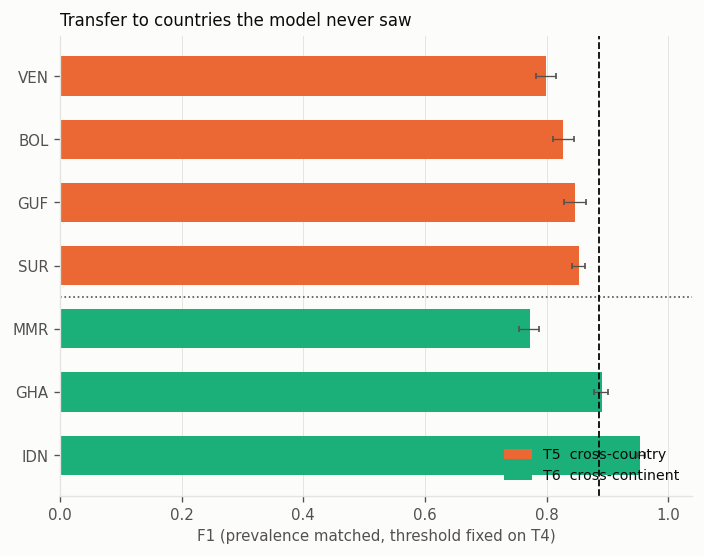


saved table_5_6_transfer_by_country.csv
All outputs are in: /content/drive/MyDrive/dissertation/results_classification_transfer


In [34]:
# ============================================================
# 16. Transfer to every held-out country
# ============================================================
# Held-out countries only. The training pool is not plotted: those are out-of-fold
# cross-validation scores, a different quantity, and mixing them into a transfer
# figure invites exactly the misreading this chapter is trying to avoid.
# The pooled T4 value is kept as a single dashed reference line, because the claim
# being made is that transfer performance sits alongside in-domain performance, and
# the reader needs the in-domain value on the same axis to check that claim.
fs = 'FS-A AlphaEarth'
kk = ((transfer.positive_def == POSDEF_TO_PLOT) & (transfer.feature_set == fs) &
      (transfer.model == MODEL_TO_PLOT) & (transfer.scope != 'ALL'))
tc = (transfer[kk][['scope','split','n_eval','precision','recall',
                    'f1','f1_lo','f1_hi']]
      .rename(columns={'scope':'country','split':'tier'})
      .sort_values(['tier','f1']).reset_index(drop=True))

pooled = transfer[(transfer.positive_def == POSDEF_TO_PLOT) &
                  (transfer.feature_set == fs) & (transfer.model == MODEL_TO_PLOT) &
                  (transfer.scope == 'ALL')].set_index('split')
t4_ref = float(r4.f1)

print('=== Transfer by held-out country ===')
print(tc.round(3).to_string(index=False))
for tier in ['T5', 'T6']:
    if tier in pooled.index:
        print(f"\n  {tier} pooled: F1 {pooled.loc[tier,'f1']:.3f} "
              f"[{pooled.loc[tier,'f1_lo']:.3f}, {pooled.loc[tier,'f1_hi']:.3f}]   "
              f"vs in-domain T4 {t4_ref:.3f}  ({pooled.loc[tier,'f1'] - t4_ref:+.3f})")
print(f"\n  Held-out range: {tc.f1.min():.3f} ({tc.loc[tc.f1.idxmin(),'country']}) "
      f"to {tc.f1.max():.3f} ({tc.loc[tc.f1.idxmax(),'country']})")
print(f"  Countries at or above the in-domain T4 value: "
      f"{int((tc.f1 >= t4_ref).sum())} of {len(tc)}")

fig, ax = plt.subplots(figsize=(6.8, 0.44*len(tc) + 1.9))
y = np.arange(len(tc))
cmap = {'T5': PAL['series'][1], 'T6': PAL['series'][2]}
ax.barh(y, tc.f1, color=[cmap[t] for t in tc.tier], height=0.62)
ax.errorbar(tc.f1, y, xerr=[tc.f1 - tc.f1_lo, tc.f1_hi - tc.f1],
            fmt='none', ecolor=PAL['ink2'], elinewidth=0.8, capsize=2)
n_t5 = int((tc.tier == 'T5').sum())
if 0 < n_t5 < len(tc):
    ax.axhline(n_t5 - 0.5, color=PAL['ink2'], lw=1.0, ls=':')
ax.axvline(t4_ref, color=PAL['ink'], ls='--', lw=1.1)
ax.annotate(f'in-domain reference (T4) = {t4_ref:.3f}', (t4_ref, len(tc) - 0.35),
            xytext=(-5, 0), textcoords='offset points', ha='right',
            fontsize=8, color=PAL['ink2'])
ax.set_yticks(y); ax.set_yticklabels(tc.country, fontsize=9)
ax.invert_yaxis()
ax.set_xlim(0, 1.04); ax.set_xlabel('F1 (prevalence matched, threshold fixed on T4)')
ax.xaxis.grid(True); ax.set_axisbelow(True)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor=PAL['series'][1], label='T5  cross-country'),
                   Patch(facecolor=PAL['series'][2], label='T6  cross-continent')],
          fontsize=8.5, loc='lower right')
ax.set_title('Transfer to countries the model never saw', loc='left')
save_fig(fig, 'F5_6_transfer_by_country'); plt.show()

tc.to_csv(OUT_DIR / 'table_5_6_transfer_by_country.csv', index=False)
print('\nsaved table_5_6_transfer_by_country.csv')
print('All outputs are in:', OUT_DIR)

In [35]:
# ============================================================
# 17. Where do the false positives come from in each held-out country?
# ============================================================
# Myanmar returns precision 0.714 with mean predicted probability 0.324 on its
# LABELLED NEGATIVES - two to six times every other held-out country. There are
# exactly two explanations and they need different responses:
#
#   (i)  genuine confusion. Kachin gold is worked in and beside active river
#        channels, so mining and turbid water are closer together in embedding
#        space there than anywhere in the training data. This is a finding and
#        goes in the text.
#   (ii) contaminated negatives. A reach drawn as te_river_turbid_neg that in
#        fact contains dredges is mining, so the model is right and the label is
#        wrong. This is a data error and must be fixed before the numbers are
#        reported.
#
# The two look identical in the F1 table and completely different here.
fs  = 'FS-A AlphaEarth'
thr = float(r4.threshold)
d_te, _ = transfer_oof[(POSDEF_TO_PLOT, fs, MODEL_TO_PLOT)]

print('='*78)
print('Predicted probability on LABELLED NEGATIVES, by class and country')
print('='*78)
neg = d_te[d_te.y == 0]
tab = (neg.groupby(['country_iso3', 'label'])['_p']
       .agg(n='size', mean_p='mean',
            frac_above=lambda v: (v >= thr).mean()).round(3).reset_index())
piv = tab.pivot(index='label', columns='country_iso3', values='mean_p')
print(piv.round(3).to_string())
print('\n  A single negative class high in ONE country -> look at that class there.')
print('  Every negative class high in one country     -> a global score shift.')

for iso in ['MMR']:
    t = tab[tab.country_iso3 == iso].sort_values('mean_p', ascending=False)
    if not len(t): continue
    print(f'\n--- {iso}: negatives ranked by mean predicted probability ---')
    print(t[['label','n','mean_p','frac_above']].to_string(index=False))
    fp = int((neg[(neg.country_iso3 == iso)]['_p'] >= thr).sum())
    print(f'  {fp} of {int((neg.country_iso3==iso).sum())} labelled negative pixels '
          f'are called mining at the fixed threshold.')

print('\n' + '='*78)
print('The individual negative POLYGONS driving it (top 12)')
print('='*78)
np_ = (neg[neg.country_iso3 == 'MMR'].groupby(['label','polygon_id'])['_p']
       .agg(n_px='size', mean_p='mean',
            frac_above=lambda v: (v >= thr).mean()).round(3)
       .reset_index().sort_values('mean_p', ascending=False))
print(np_.head(12).to_string(index=False))
print('\n  Open the top few in GEE on the SWIR composite.')
print('  If you can see dredges, ponds or bare worked banks inside them, they are')
print('  mislabelled negatives: either redraw them or move them to a positive layer,')
print('  re-export MMR only, and re-run. If they are genuinely undisturbed river,')
print('  then Myanmar is a real confusion case and the number stands as it is.')

print('\n' + '='*78)
print('For comparison: the same for the positives that are being missed')
print('='*78)
pos = d_te[(d_te.y == 1) & (d_te.country_iso3 == 'MMR')]
pp = (pos.groupby(['label','polygon_id'])['_p']
      .agg(n_px='size', mean_p='mean',
           frac_above=lambda v: (v >= thr).mean()).round(3)
      .reset_index().sort_values('frac_above'))
print(pp.head(10).to_string(index=False))

tab.to_csv(OUT_DIR / 'table_B2_negatives_by_class.csv', index=False)
np_.to_csv(OUT_DIR / 'table_B3_mmr_negative_polygons.csv', index=False)
print('\nsaved table_B2_negatives_by_class.csv, table_B3_mmr_negative_polygons.csv')


Predicted probability on LABELLED NEGATIVES, by class and country
country_iso3                              BOL    GHA    GUF    IDN    MMR    SUR    VEN
label                                                                                  
agriculture_negative                      NaN  0.002    NaN    NaN    NaN    NaN    NaN
agriculture_within_vegetation_negative  0.514  0.035    NaN  0.096    NaN  0.140  0.167
forest_negative                         0.014  0.020  0.009  0.013  0.126  0.018  0.250
river_negative                            NaN    NaN  0.293    NaN    NaN  0.039    NaN
turbid_braided_river_negative           0.711  0.879    NaN  0.122  0.635  0.897  0.839
urban_bare_negative                     0.087  0.053  0.117  0.085  0.382  0.015  0.085

  A single negative class high in ONE country -> look at that class there.
  Every negative class high in one country     -> a global score shift.

--- MMR: negatives ranked by mean predicted probability ---
                     

AMW file  : /content/drive/MyDrive/dissertation/amw_scar2024_test_boxes.geojson
AMW polygons: 2,128   median 6.48 ha   total 133,432 ha

Held-out pixels in AMW-covered countries: 14,366

0.  Coverage - how much of the sample AMW actually speaks to
              pixels  inside_amw  amw_polys_touched  pct_inside
country_iso3                                                   
BOL             3213        2202                  8        68.5
GUF             2929        1631                  6        55.7
SUR             4766        1949                  6        40.9
VEN             3458        2079                  6        60.1

  AMW polygons touched by the sample: 26 of 2,128
  Everything below is conditional on this sample. The negatives are where
  negatives were drawn, not a random sample of the landscape, so these are
  agreement rates on the labelled sample and not landscape-level rates.

Q1.  Model against AMW  (the external validation)
            n  AMW+ model+  AMW+ model-  AMW-

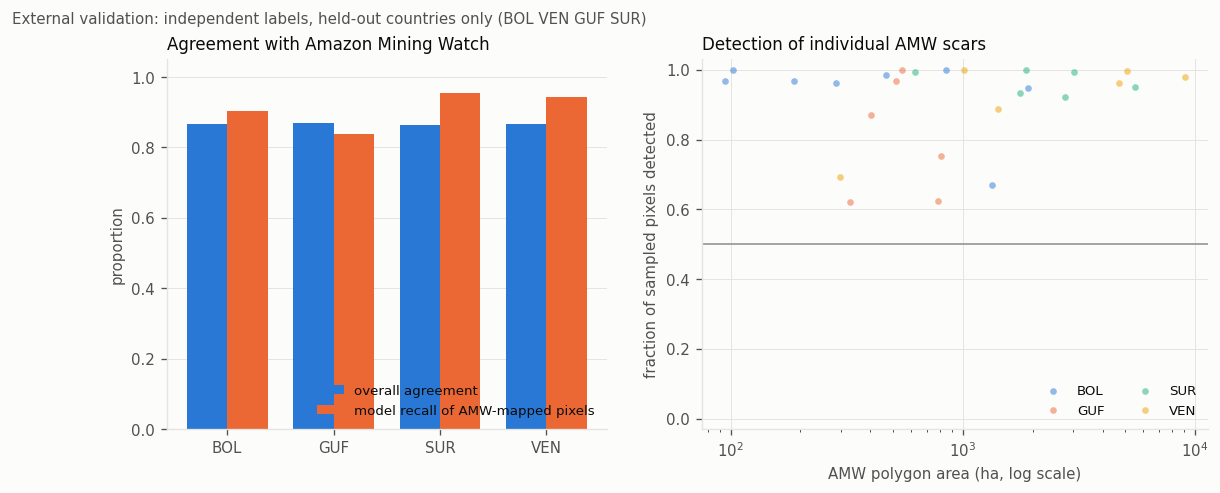


saved table_5_13 / 5_14 / 5_15 and F5_11


In [37]:
# ============================================================
# 18. External validation against Amazon Mining Watch
# ============================================================
# Amazon Mining Watch (Earth Genome) maps mining scars across the Amazon basin
# with an independent method - a convolutional segmentation model over Sentinel-2,
# refined with SAM2 - independent labels, independent imagery pipeline, and no
# contact with this study. It covers BOL, VEN, GUF and SUR, which is exactly the
# T5 held-out set, and does not cover ECU, GHA, IDN or MMR.
#
# WHAT THIS IS AND IS NOT
#   It is: agreement between two independent detectors on the same ground.
#   It is NOT: an accuracy assessment. AMW is a model, not ground truth. Its own
#   reported sensitivity is 0.895 on a Venezuelan hold-out, its segmentation is
#   documented as running large, and it maps CUMULATIVE scars to 2024, so a pit
#   abandoned in 2019 and revegetated by 2024 is AMW-positive and correctly
#   negative here. Every number below is therefore reported as agreement, and
#   disagreement is not automatically this study's error.
#
# Three questions, in order of how much they are worth:
#   Q1  Does the model detect the mining that an independent product mapped?
#   Q2  Do the hand-drawn labels agree with that product?  (labelling audit)
#   Q3  Where model and AMW agree against the hand label, is the label wrong?
import warnings, glob
warnings.filterwarnings('ignore')
try:
    import geopandas as gpd
    from shapely.geometry import Point
except Exception:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'geopandas', 'shapely', 'pyproj'])
    import geopandas as gpd
    from shapely.geometry import Point

AMW_COUNTRIES = ['BOL', 'VEN', 'GUF', 'SUR']
EQ_AREA = 'EPSG:6933'          # equal-area, for hectares

# ---- locate the file ------------------------------------------------------
cands = []
for d in SEARCH_DIRS:
    cands += sorted(glob.glob(str(d / '**' / 'amw_scar2024_test_boxes.geojson'),
                              recursive=True))
    cands += sorted(glob.glob(str(d / 'amw*test_boxes*.geojson')))
cands = list(dict.fromkeys(cands))
if not cands:
    raise FileNotFoundError(
        'amw_scar2024_test_boxes.geojson not found in SEARCH_DIRS. '
        'Put it in MyDrive/dissertation/ and re-run this cell.')
AMW_PATH = cands[0]
amw = gpd.read_file(AMW_PATH)
if amw.crs is None:
    amw = amw.set_crs('EPSG:4326')
amw = amw.to_crs('EPSG:4326')
amw['amw_id'] = np.arange(len(amw))
amw['amw_area_ha'] = amw.to_crs(EQ_AREA).area / 1e4
print('AMW file  :', AMW_PATH)
print(f'AMW polygons: {len(amw):,}   median {amw.amw_area_ha.median():.2f} ha   '
      f'total {amw.amw_area_ha.sum():,.0f} ha')

# ---- the model's predictions on the held-out pixels ------------------------
fs  = 'FS-A AlphaEarth'
thr = float(r4.threshold)
d_te, _ = transfer_oof[(POSDEF_TO_PLOT, fs, MODEL_TO_PLOT)]
sub = d_te[d_te.country_iso3.isin(AMW_COUNTRIES)].copy()
sub['pred'] = (sub['_p'] >= thr).astype(int)
print(f'\nHeld-out pixels in AMW-covered countries: {len(sub):,}')

pts = gpd.GeoDataFrame(
    sub, geometry=gpd.points_from_xy(sub.longitude, sub.latitude),
    crs='EPSG:4326')
j = gpd.sjoin(pts, amw[['amw_id', 'amw_area_ha', 'geometry']],
              how='left', predicate='within')
j = j[~j.index.duplicated(keep='first')]          # a point can land in overlaps
j['amw'] = j.amw_id.notna().astype(int)

print('\n' + '='*76)
print('0.  Coverage - how much of the sample AMW actually speaks to')
print('='*76)
cov = (j.groupby('country_iso3')
       .agg(pixels=('amw', 'size'), inside_amw=('amw', 'sum'),
            amw_polys_touched=('amw_id', 'nunique')).astype(int))
cov['pct_inside'] = (100*cov.inside_amw/cov.pixels).round(1)
print(cov.to_string())
print(f'\n  AMW polygons touched by the sample: {int(j.amw_id.nunique()):,} '
      f'of {len(amw):,}')
print('  Everything below is conditional on this sample. The negatives are where')
print('  negatives were drawn, not a random sample of the landscape, so these are')
print('  agreement rates on the labelled sample and not landscape-level rates.')

# ---- Q1: does the model find what AMW mapped? -----------------------------
print('\n' + '='*76)
print('Q1.  Model against AMW  (the external validation)')
print('='*76)
rows = []
for iso, g in j.groupby('country_iso3'):
    a, p = g.amw.values, g.pred.values
    both = int(((a == 1) & (p == 1)).sum()); amw_only = int(((a == 1) & (p == 0)).sum())
    mod_only = int(((a == 0) & (p == 1)).sum()); neither = int(((a == 0) & (p == 0)).sum())
    rows.append({'country': iso, 'n': len(g),
                 'AMW+ model+': both, 'AMW+ model-': amw_only,
                 'AMW- model+': mod_only, 'AMW- model-': neither,
                 'agreement': (both + neither)/len(g),
                 'model_recall_of_AMW': both/max(both + amw_only, 1)})
q1 = pd.DataFrame(rows).set_index('country').round(3)
print(q1.to_string())
tot = j
b = int(((tot.amw == 1) & (tot.pred == 1)).sum()); ao = int(((tot.amw == 1) & (tot.pred == 0)).sum())
mo = int(((tot.amw == 0) & (tot.pred == 1)).sum()); nn = int(((tot.amw == 0) & (tot.pred == 0)).sum())
print(f'\n  Pooled: agreement {(b+nn)/len(tot):.3f}   '
      f'model recall of AMW-mapped pixels {b/max(b+ao,1):.3f}')
print('  "AMW- model+" is not necessarily a false positive: AMW omissions are')
print('  documented, and its own hold-out sensitivity is 0.895.')

# per-AMW-polygon detection rate - the headline number
pp = (j[j.amw == 1].groupby('amw_id')
      .agg(n_px=('pred', 'size'), frac_detected=('pred', 'mean'),
           mean_p=('_p', 'mean'),
           country=('country_iso3', 'first'),
           area_ha=('amw_area_ha', 'first')).reset_index())
pp = pp[pp.n_px >= 3]
if len(pp):
    print(f'\n  Per-AMW-polygon detection, {len(pp):,} polygons with 3+ sampled pixels:')
    print(f'    median detected fraction {pp.frac_detected.median():.3f}')
    print(f'    polygons with >50% of sampled pixels detected: '
          f'{(pp.frac_detected > 0.5).mean():.1%}')
    print(f'    polygons with 0% detected:                     '
          f'{(pp.frac_detected == 0).mean():.1%}')
    print('\n  By country:')
    print(pp.groupby('country').agg(n_poly=('amw_id','size'),
                                    median_frac=('frac_detected','median'),
                                    median_ha=('area_ha','median')).round(3).to_string())

# ---- Q2: do the hand-drawn labels agree with AMW? -------------------------
print('\n' + '='*76)
print('Q2.  Hand-drawn labels against AMW  (labelling audit)')
print('='*76)
rows = []
for iso, g in j.groupby('country_iso3'):
    a, h = g.amw.values, g.y.values
    both = int(((a==1)&(h==1)).sum()); amw_only = int(((a==1)&(h==0)).sum())
    lab_only = int(((a==0)&(h==1)).sum()); neither = int(((a==0)&(h==0)).sum())
    po = (both+neither)/len(g)
    pe = ((a.mean()*h.mean()) + ((1-a.mean())*(1-h.mean())))
    rows.append({'country': iso, 'n': len(g), 'agreement': po,
                 'kappa': (po-pe)/max(1-pe, 1e-9),
                 'AMW+ label-': amw_only, 'AMW- label+': lab_only})
q2 = pd.DataFrame(rows).set_index('country').round(3)
print(q2.to_string())
print('\n  "AMW+ label-" is expected and mostly benign: AMW segmentation runs large')
print('  and its scars are cumulative, so its polygons extend past the active')
print('  workings that were labelled here.')

# ---- Q3: model and AMW agreeing against the hand label --------------------
print('\n' + '='*76)
print('Q3.  Both detectors say mining, the hand label says otherwise')
print('='*76)
susp = j[(j.amw == 1) & (j.pred == 1) & (j.y == 0)]
if len(susp):
    t = (susp.groupby(['country_iso3', 'label', 'polygon_id'])
         .agg(n_px=('_p','size'), mean_p=('_p','mean')).round(3)
         .reset_index().sort_values('n_px', ascending=False))
    print(f'{len(susp):,} pixels; the negative polygons they sit in:')
    print(t.head(15).to_string(index=False))
    print('\n  These are the highest-value polygons to re-inspect: two independent')
    print('  detectors disagree with the hand label in the same direction.')
    print('  Correct a label only if the SWIR imagery shows mining. Agreement')
    print('  between two models is a reason to look, never a reason to relabel.')
    t.to_csv(OUT_DIR/'table_B4_amw_model_vs_label.csv', index=False)
else:
    print('None - no labelled negative is called mining by both detectors.')

# ---- figure ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.0),
                         gridspec_kw={'width_ratios': [1, 1.15]})
c = q1.index.tolist(); x = np.arange(len(c)); w = 0.38
axes[0].bar(x - w/2, q1.agreement, w, color=PAL['series'][0], label='overall agreement')
axes[0].bar(x + w/2, q1.model_recall_of_AMW, w, color=PAL['series'][1],
            label='model recall of AMW-mapped pixels')
axes[0].set_xticks(x); axes[0].set_xticklabels(c, fontsize=9)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel('proportion')
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)
axes[0].legend(fontsize=8, loc='lower right')
axes[0].set_title('Agreement with Amazon Mining Watch', loc='left')

if len(pp):
    for i, (iso, g) in enumerate(pp.groupby('country')):
        axes[1].scatter(g.area_ha, g.frac_detected, s=16, alpha=0.5, linewidths=0,
                        c=PAL['series'][i % len(PAL['series'])], label=iso)
    axes[1].set_xscale('log')
    axes[1].axhline(0.5, color=PAL['muted'], lw=0.9)
    axes[1].set_xlabel('AMW polygon area (ha, log scale)')
    axes[1].set_ylabel('fraction of sampled pixels detected')
    axes[1].set_ylim(-0.03, 1.03)
    axes[1].legend(fontsize=8, loc='lower right', ncol=2)
    axes[1].grid(True); axes[1].set_axisbelow(True)
    axes[1].set_title('Detection of individual AMW scars', loc='left')
fig.suptitle('External validation: independent labels, held-out countries only '
             '(BOL VEN GUF SUR)', x=0.01, ha='left', fontsize=9, color=PAL['ink2'])
save_fig(fig, 'F5_11_amw_external_validation'); plt.show()

q1.to_csv(OUT_DIR/'table_5_13_amw_model_agreement.csv')
q2.to_csv(OUT_DIR/'table_5_14_amw_label_agreement.csv')
if len(pp): pp.to_csv(OUT_DIR/'table_5_15_amw_per_polygon.csv', index=False)
print('\nsaved table_5_13 / 5_14 / 5_15 and F5_11')
